In [1]:
# Basic libraries for working with files and data
import os
from pathlib import Path

# Libraries for plotting and visualizing images/data
import matplotlib.pyplot as plt
import seaborn as sns

# Library for opening image files
from PIL import Image

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Define paths to the training and testing folders.
# These paths are relative to this notebook's location inside the notebooks/ folder.

train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

print("Training path exists:", train_dir.exists())
print("Testing path exists:", test_dir.exists())

Training path exists: True
Testing path exists: True


In [3]:
# Each folder inside Training represents one class/category.
# For this dataset, we expect classes like glioma, meningioma, pituitary, and notumor.

classes = sorted([folder.name for folder in train_dir.iterdir() if folder.is_dir()])

print("Classes found:")
for c in classes:
    print("-", c)

Classes found:
- glioma
- meningioma
- notumor
- pituitary


In [4]:
# Count how many images exist in each class folder for both training and testing.
# This helps us check whether the dataset is balanced or imbalanced.

image_extensions = [".jpg", ".jpeg", ".png"]

train_counts = {}
test_counts = {}

for c in classes:
    train_class_path = train_dir / c
    test_class_path = test_dir / c
    
    train_images = [
        file for file in train_class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    test_images = [
        file for file in test_class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    train_counts[c] = len(train_images)
    test_counts[c] = len(test_images)

print("Training image counts:")
print(train_counts)

print("\nTesting image counts:")
print(test_counts)

Training image counts:
{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}

Testing image counts:
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


In [5]:
# Convert the class counts into a clean table.
# This makes it easier to read and later include in the project report.

import pandas as pd

class_distribution = pd.DataFrame({
    "Class": classes,
    "Training Count": [train_counts[c] for c in classes],
    "Testing Count": [test_counts[c] for c in classes]
})

class_distribution

,Class,Training Count,Testing Count
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


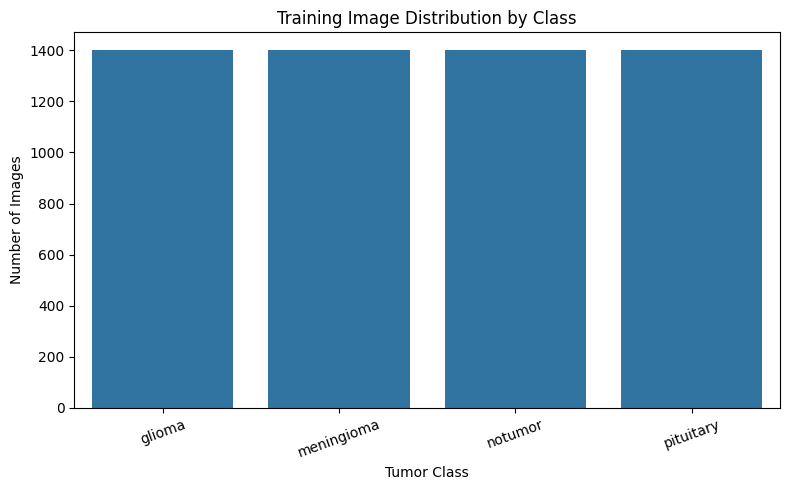

In [6]:
# Create a bar chart showing the number of training images in each class.
# This visualization helps identify whether the dataset is balanced.

plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_distribution,
    x="Class",
    y="Training Count"
)

plt.title("Training Image Distribution by Class")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

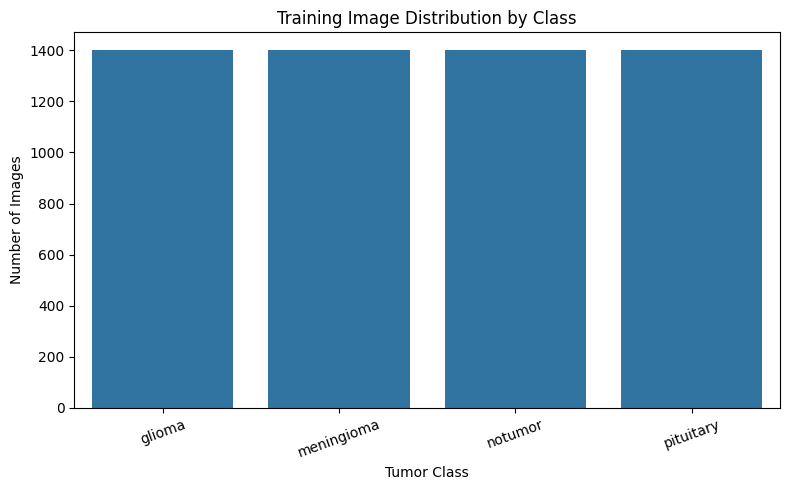

In [7]:
# Save the class distribution graph so we can use it later in the final paper.

plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_distribution,
    x="Class",
    y="Training Count"
)

plt.title("Training Image Distribution by Class")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=300)
plt.show()

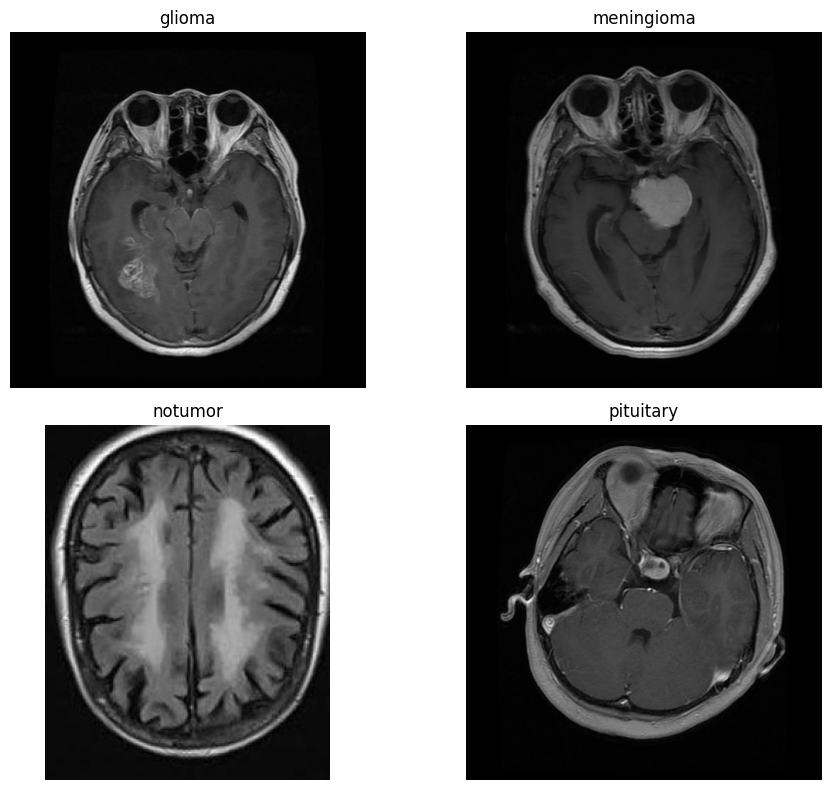

In [8]:
# Display one sample MRI image from each class.
# This helps us visually inspect the dataset and confirm that images are loading correctly.

plt.figure(figsize=(10, 8))

for i, c in enumerate(classes):
    class_path = train_dir / c
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    sample_image_path = image_files[0]
    img = Image.open(sample_image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

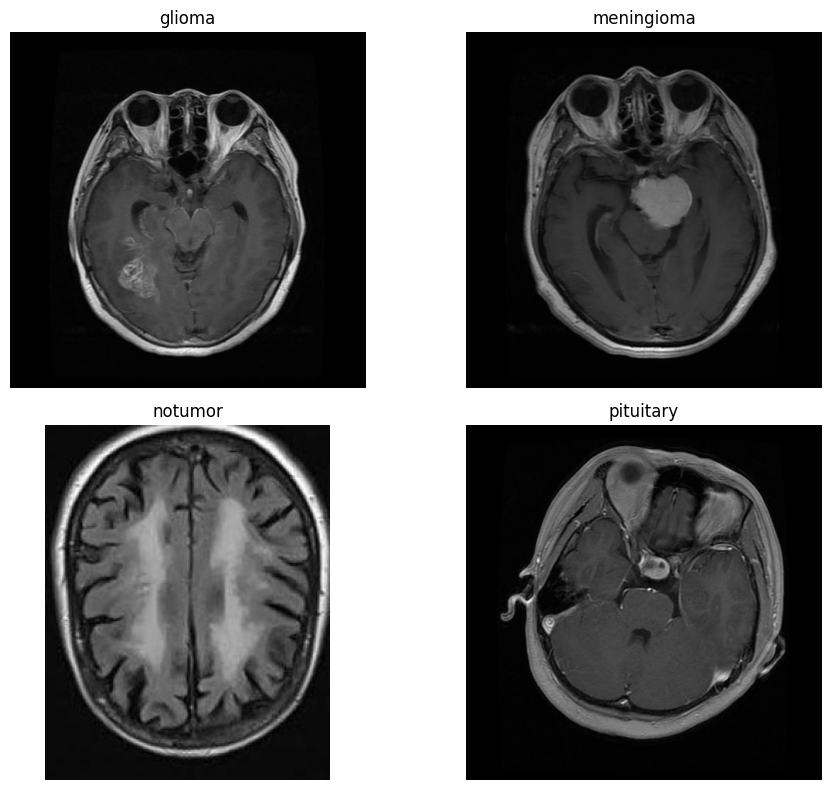

In [9]:
# Save the sample MRI image grid for later use in the final report.

plt.figure(figsize=(10, 8))

for i, c in enumerate(classes):
    class_path = train_dir / c
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    sample_image_path = image_files[0]
    img = Image.open(sample_image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../figures/sample_mri_images.png", dpi=300)
plt.show()

In [14]:
from PIL import Image
from pathlib import Path

data_dir = Path("../data")
image_extensions = {".jpg", ".jpeg", ".png"}

image_sizes = []
bad_files = []

for folder in [data_dir / "training", data_dir / "testing"]:
    image_files = [
        file for file in folder.rglob("*")
        if file.suffix.lower() in image_extensions
    ]

    for image_path in image_files[:50]:
        try:
            with Image.open(image_path) as img:
                image_sizes.append(img.size)
        except Exception as e:
            bad_files.append((image_path, str(e)))

unique_sizes = set(image_sizes)

print("Unique image sizes:", unique_sizes)
print("Bad files:", bad_files[:10])

Unique image sizes: {(1338, 1304), (512, 512), (256, 256), (225, 225)}
Bad files: []


## Data Exploration Summary

In this notebook, we inspected the Brain MRI dataset structure, identified the available tumor classes, counted the number of images in each class, visualized class distribution, and displayed sample MRI scans. This step helps identify potential class imbalance and confirms that image preprocessing, including resizing and normalization, will be necessary before model training.
